# COGS 108 - EDA Checkpoint

#### Authors

- Kenric Hoang: Conceptualization, Data curation, Writing - original draft
- Deborah Kim: Conceptualization, Writing - original draft
- Andy Tang: Methodology, Software, Visualization (?), Writing - review & editing
- Aidan Tjon: Software, Project Admin, Investigation, Writing - original draft

# Research Question

Do performance gains on standardized LLM benchmarks exhibit diminishing returns in terms of estimated inference cost, when scaled up? Performance will be measured utilizing scores from different benchmarks such as MMLU and GSM8K. Environmental costs will be measured through available proxies for computation power such as model parameter count and estimated FLOPs per token. This project involves statistical inference with exploratory modelling in order to draw a relationship between performance metrics and increasing compute costs. Examining this relationship, we can find out whether marginal increases in performance require a disproportionate surge in computational, and thus environmental costs.

## Background and Prior Work

Even as generative AI has seen rapid, mainstream adoption, a fundamental problem in the race to train the latest and greatest LLM models has been the sustainability of training and running each model. To bring a response to an end user query, the associated model must have first been trained with enormous text datasets, or of the most recent multimodal models inputs such as image / video as well, before processing the query with its associated inference engine, also requiring computational power to piece together a response for the user. Of which, these data sources for models have been growing exponentially, requiring a similar exponential growth in computational power required.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1)

The amount of computational complexity within each step is, unfortunately, obfuscated to the end user. Each generative AI company’s flagship model exists solely within a black box, where the computational power required to answer a query is unknown, and while time to perform inference has been the most common metric<a name="cite_ref-2"></a>[<sup>2, </sup>](#cite_note-2)<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) as to calculate the environmental impact, the transformer models that underline all LLMs are highly parallelizable, obfuscating the real computational time required by spreading the query across multiple servers. HELM, a framework for LLM comparison created by the Center for Research on Foundation Models at Stanford, attempts to normalize the metric by running each model on the same hardware.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

We see real impacts to this computational complexity, server farms come at a massive cost, not only through power, but water use for cooling, costs to create the hardware going into server farms, to properly dispose of e-waste at the end of its useful lifecycle (shortened by intense usage), and in some cases, noise pollution to nearby residential environment when improperly placed. Not only that, the rapid adoption of LLMs has led to a developmental style that runs counter to that of long-term sustainability<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1), both in terms of environmental impacts, but also longevity of several AI firms, focusing on output performance. 

As we address today, using the data we have access to, we want to put forward some rough ideas for how model performance relates to the environmental cost of each model. We understand this analysis is underscored by power and computational cost not being a priority for those who train frontier models. 


1. <a name="cite_note-1"></a> [^](#cite_ref-1) Wu, C. et. al. (Jan 2022) Sustainable AI: Environmental Implications, Challenges and Opportunities. *Proceedings of Machine Learning and Systems 4.* https://arxiv.org/abs/2111.00364
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Liang, P. et. al. (Aug 2023) Holistic Evaluation of Language Models. *Transactions on Machine Learning Research.* https://arxiv.org/pdf/2211.09110
2. <a name="cite_note-3"></a> [^](#cite_ref-3) huggingface.co (Date Unknown) Open LLM Leaderboard. *Huggingface.co.* https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard#/

# Hypothesis


Do performance gains on standardized LLM benchmarks exhibit diminishing returns in terms of estimated inference cost, when scaled up? 

To what extent do performance gains on LLMs exhibit diminishing returns in terms of inference cost, as the model size increases? We predict that the relationship between inference cost (parameter count and FLOPs) per token and model performance evaluated by benchmark scores are directly proportional. As model scale increases, we believe benchmark scores will keep improving, but the performance gain per unit of inference cost will decrease. We predict models under 70B parameters will show linear performance gains, while models exceeding this will show significant diminishing returns.


## Data

### Data overview

Dataset #1
- Dataset Name: Hugging Face Open LLM Leaderboard
- Link to the dataset: https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard#/
- Number of observations: 4576 models
- Number of variables: Filtered to 3 data points plus identification, family of model. The cleaning program allows us to keep a larger set if necessary, such as individual benchmark scores as opposed to average.
- Description of the variables most relevant to this project:
  - `co2_cost`: reported carbon emissions for the evaluation run (kg CO2), used as our proxy for environmental cost. In theory, we could also use this to backsolve for computational power. 
  - `average_score`: benchmark scores normalized 0-100 before averaging, scores include BBH, GQPA, IFeval, MATH, mmlu-pro, musr. These open benchmarks evaluate the performance of Large Language models in various fields.
  - `precision`: floating-point precision used for the model (bit depth; e.g., 16-bit, 8-bit)
  - `parameters`: The main source of comparison provided by this dataset. Parameters, or inputs to a model, are a sign of the model’s complexity, and are associated with longer training and inference times and cost. 
- Descriptions of any shortcomings this dataset has with respect to the project:
  - Focuses on models that are submitted to the leaderboard (selection bias toward open models)
  - CO2 values are reported or estimated for evaluation runs rather than full training energy
  - Some fields may be missing or inconsistently reported across models


Dataset #2
- Dataset Name: Epoch AI Models Dataset (`all_ai_models.csv`)
- Link to the dataset: https://epoch.ai/data/ai-models
- Number of observations: 3,240 models
- Number of variables: 56 columns
- Description of the variables most relevant to this project:
  - `Training compute (FLOPs)`: theoretical training compute (floating-point operations; unitless count)
  - `Training hardware`: GPU/accelerator type used (categorical)
  - `Parameters`: model parameter count (unitless; typically reported in billions)
- Descriptions of any shortcomings this dataset has with respect to the project:
  - Compute values are sometimes estimated or derived rather than directly measured
  - Coverage includes many non-LLM models, so we must filter to comparable language models
  - Missingness in compute or hardware fields for some entries


Dataset #3
- Dataset Name: Stanford HELM (Holistic Evaluation of Language Models)
- Link to the dataset: https://github.com/stanford-crfm/helm
- Number of observations: 2594610, each model has several.. 
- Number of variables: 717 (raw)
- Description of the variables most relevant to this project:
  - `denoised_inference_runtime`: normalized inference runtime metric (unitless; lower is faster)
  - `model_name`: model identifier used for cross-referencing with other datasets
- Descriptions of any shortcomings this dataset has with respect to the project:
  - Benchmark coverage is limited to the models included in a given HELM release
  - Runtime is measured on standardized hardware and may not reflect real-world deployment
  - Model naming conventions may not align perfectly with other datasets


We plan to use analyze these 3 datasets seperately. We can make cross-comparisons acrosss these datasets, if necessary. Epoch provides training compute and hardware metadata, while Hugging Face and HELM provide performance and inference-cost proxies.



### Dataset 1: Hugging Face Open LLM Leaderboard

This dataset is our primary source for linking model performance to estimated environmental impact at the model level. In the cleaned file (`data/Output/hf_parameters_co2.ndjson`), each row represents a unique model, yielding 4,465 observations across 13 variables. The most important fields for our question are `co2_cost` (reported in kg CO2e), `average_score` (aggregate benchmark performance score), `parameters` (absolute parameter count), and `precision` (for example `bfloat16`, `float16`, and a small number of `4bit` entries). Together, these let us estimate how much benchmark gain is associated with larger model size and greater estimated carbon cost.

A major strength here is that the dataset combines multiple benchmark families (`bbh`, `gpqa`, `ifeval`, `math`, `mmlu_pro`, `musr`) under one model identifier, which gives broader coverage than relying on a single benchmark. However, there are important caveats. First, this is not a random sample of all LLMs; it is mostly models submitted to or tracked by the leaderboard, so representation bias is expected. Second, the cleaning step collapses duplicates by model and averages scores/cost fields, which improves consistency but can hide run-level variation. Third, we detected suspicious values: three models have `parameters = -1e9`, which is not physically meaningful and should be flagged/excluded before regression or correlation analyses.


In [1]:
import polars as pl
import os
import pandas as pd

# Directories need closing slashes /
generate_files = False
src = "./data/Input/huggingface/formatted.json"
temp_dir = "./data/temp/"
output_dir = "./data/Output/"

# Open raw from src
hf_raw = pl.read_json(src)
print(f"Hugging Face raw shape (before cleaning): {hf_raw.shape}")
hf = hf_raw.lazy()

# Seperate model into individual columns. Polars interprets dictionaries as "struct" dtype.
hf = hf.unnest(["model", "evaluations", "features", "metadata"])

# Drop columns
hf = hf.drop([
    "base_model",
    "has_chat_template",
    "hub_license",
    "id",
    "is_flagged",
    "is_merged",
    "is_not_available_on_hub",
    "sha",


])


# Potentially dropped columns (we can discuss)
hf = hf.drop([
    "generation",
    "hub_hearts",
    "is_moe", # Unknown var
    "is_official_provider",
    "submission_date",
    "type", # Type of LLM?
    "upload_date",
    "weight_type", # if using adapter https://huggingface.co/docs/hub/adapters

])

# creating analysis files
if generate_files:
    for cols in hf.drop(pl.col("name")).collect().columns:
        hf.select([cols, "name"]).unique().sort(by=cols, descending=True).sink_ndjson(f"{temp_dir}hf_{cols}.ndjson")

# expand params_billions to parameters (to match epoch dataset)
hf = hf.with_columns((pl.col("params_billions") * 1000000000).alias("parameters")).drop("params_billions")

# Add column with model name without contributor
hf = hf.with_columns((pl.col("name").str.split("/").list.get(-1)).alias("model"))

# duplicates exist, collapse by model
hf = hf.group_by("model").agg([
    pl.col("architecture").first(),
    pl.col("average_score").mean(),
    pl.col("co2_cost").mean(),
    pl.col("parameters").mean(),
    pl.col("precision").first(),
    pl.col("name"),
    pl.col("bbh"),
    pl.col("gpqa"),
    pl.col("ifeval"),
    pl.col("math"),
    pl.col("mmlu_pro"),
    pl.col("musr"),
])

hf.sort(["architecture", "model"]).sink_ndjson(f"{output_dir}hf_parameters_co2.ndjson")

hf_df = pd.read_json("data/Output/hf_parameters_co2.ndjson", lines=True)
print(f"Hugging Face cleaned shape (after cleaning): {hf_df.shape}")

hf_key_cols = ["model", "average_score", "co2_cost", "parameters", "precision"]
hf_df[hf_key_cols].head()



Hugging Face raw shape (before cleaning): (4576, 5)
Hugging Face cleaned shape (after cleaning): (4465, 13)


,model,average_score,co2_cost,parameters,precision
0,Llama-3.2-3B-Instruct-unsloth-bnb-4bitlora_model,17.182397,1.721414,1.933000e+09,float16
1,llama31_8B_en_emo_v4,17.153621,1.797343,4.777000e+09,float16
2,mistral_dpo_self,9.824436,2.263063,7.913000e+09,bfloat16
3,phi-4-14b,29.913840,1.351959,1.470400e+10,bfloat16
4,phi-4-1steps,29.870388,1.345177,1.470400e+10,bfloat16


### Dataset 2: Epoch AI Models Dataset

This dataset provides training-side compute metadata that the Hugging Face leaderboard does not provide directly. After filtering to language-domain entries and dropping rows with null `Parameters`, the cleaned file (`data/Output/epoch_ai_parameters.ndjson`) contains 1,403 observations and 14 variables. Core variables include `Parameters`, `Training compute (FLOP)`, `Training chip-hours`, `Training hardware`, and `Publication date`, plus boolean indicators such as `Frontier model`, `Foundation model`, and `Notable`. These variables are essential for estimating whether training-scale increases produce diminishing practical returns when combined with downstream benchmark performance.

The main limitation of this dataset is missingness in compute-related fields. In the cleaned table, `Training chip-hours` is missing for 90.31% of rows, `Batch size` for 85.53%, and `Finetune compute (FLOP)` for 84.03%. Even key fields like `Training compute (FLOP)` still have 41.91% missingness. This means we cannot assume complete-case analyses are unbiased; we will need targeted filtering and sensitivity checks. Another concern is heterogeneity in model scope: although filtered for language relevance, many rows are still multimodal or mixed-domain entries, which can confound direct comparisons if not controlled during analysis.


In [2]:
import polars as pl
import os
import pandas as pd

# Directories need closing slashes /
generate_files = False
src = "./data/Input/epoch_ai_raw/all_ai_models.csv"
temp_dir = "./data/temp/"
output_dir = "./data/Output/"

# Reads epoch.ai data, defines schema for columns
epoch_raw = pl.read_csv(src, schema_overrides={
    "Batch size":pl.Float64,
    "Finetune compute (FLOP)":pl.Float64,
    "Last modified":pl.Datetime,
    "Parameters":pl.Float64,
    "Publication Date":pl.Date,
    "Training chip-hours":pl.Float64,
    "Training compute (FLOP)":pl.Float64,
    "Training dataset size (total)":pl.Utf8, # Casted to numeric later.


})
print(f"Epoch AI raw shape (before cleaning): {epoch_raw.shape}")
epoch = epoch_raw.lazy()

# Filter epoch.ai data for only language models
epoch = epoch.filter(pl.col("Domain").str.contains("Language"))

# Create Bool indicator for model notability - Done here to drop other notability columns
epoch = epoch.with_columns(pl.col("Notability criteria").is_not_null().alias("Notable"))

# Discard columns
epoch = epoch.drop([
    "Abstract",
    "Accessibility notes",
    "Approach",
    "Archived links",
    "Authors",
    "Base model",
    "Citations",
    "Dataset size notes",
    "Finetune compute notes",
    "Hugging Face developer id",
    "Link",
    "Model accessibility",
    "Notability criteria notes",
    "Notability criteria",
    "Numerical format",
    "Post-training compute (FLOP)",
    "Post-training compute notes",
    "Reference",
    "Task",
    "Training cloud compute vendor",
    "Training compute cost (2023 USD)",
    "Training compute estimation method",
    "Training compute notes",
    "Training data center",
    "Training time notes",
    "Utilization notes",
    "WikiText and Penn Treebank data",

])

# Potentially Discarded columns (we can discuss)
epoch = epoch.drop([
    "Batch size notes", # duplicate data?
    "Confidence", # unsure what it is
    "Country (of organization)",
    "Epochs", # unsure what it is
    "Hardware quantity", # unsure
    "Hardware utilization (HFU)", # unsure
    "Hardware utilization (MFU)", # unsure
    "Organization categorization",
    "Organization",
    "Parameters notes",
    "Possibly over 1e23 FLOP", # duplicate data? Is a Bool
    "Training code accessibility", # could compare open-source to closed-source models?
    "Training compute lower bound", # unknown how many have this var
    "Training compute upper bound", # same as lower bound
    "Training power draw (W)", # No unit given, if we can determine.
    "Training time (hours)", # No metric

])

# Variable specific changes
epoch = epoch.with_columns(pl.col("Training dataset size (total)").str.split(",").list.first().cast(pl.Float64))
epoch = epoch.with_columns(pl.col("Frontier model").is_not_null())
epoch = epoch.with_columns(pl.col("Foundation model").is_not_null())


# Generate files for each column (if generate_files = True)
if generate_files:
    for cols in epoch.drop(pl.col("Model")).collect().columns:
        epoch.select([cols, "Model"]).unique().sort(by=cols).sink_ndjson(f"{temp_dir}epoch_data_{cols}.ndjson")


# Drop nulls in "Parameters"
epoch = epoch.drop_nulls(pl.col(["Parameters"]))


# Export
epoch.sink_ndjson(f"{output_dir}epoch_ai_parameters.ndjson")

epoch_df = pd.read_json("data/Output/epoch_ai_parameters.ndjson", lines=True)
print(f"Epoch AI cleaned shape (after cleaning): {epoch_df.shape}")

epoch_key_cols = ["Model", "Parameters", "Training compute (FLOP)", "Training hardware", "Publication date"]
epoch_df[epoch_key_cols].head()



Epoch AI raw shape (before cleaning): (3240, 56)
Epoch AI cleaned shape (after cleaning): (1403, 14)


,Model,Parameters,Training compute (FLOP),Training hardware,Publication date
0,Solar Open 100B\n,1.020000e+11,NaN,None,2025-12-31
1,K-EXAONE,2.360000e+11,1.520000e+24,NVIDIA B200 GPUs,2025-12-31
2,VAETKI\n,1.000000e+11,NaN,Nvidia H100 80G,2025-12-30
3,A.X K1,5.190000e+11,NaN,NVIDIA H200,2025-12-30
4,HyperCLOVA X SEED 32B Think,3.200000e+10,NaN,None,2025-12-29


### Dataset 3: Stanford HELM Run Statistics

The HELM dataset gives us inference-time behavior at scale, which complements the training-focused and leaderboard-focused datasets above. In our pipeline output (`data/Output/helm_leaderboard_all_results_clean.parquet`), the cleaned table has 2,594,786 observations and 10 variables, where each row is a model-metric summary record. Key columns are `model`, `metric`, and statistical summaries (`count`, `sum`, `sum_squared`, `min`, `max`, `mean`, `variance`, `stddev`). For this project, `inference_runtime` and `inference_denoised_runtime` are especially important because they act as standardized proxies for deployment-time computational cost.

This dataset is very rich, but it has nontrivial constraints. Metrics are scenario-dependent and infrastructure-dependent, so the same model may show different runtime behavior depending on benchmark configuration and provider environment. The cleaning process also drops incomplete rows (about 7.31% dropped), which improves usability but can introduce selection effects if missingness is structured. Finally, because HELM is metric-level rather than model-level, we must aggregate carefully before joining to the other datasets; otherwise we risk overweighting models with more reported metric rows instead of more meaningful evidence.


In [3]:
# based on helm_csv_compilation.ipynb
# takes ~5min + 4gb ram to run.

import os
import json
import pandas as pd
from zipfile import ZipFile

src = "./data/Input/helm/run_stats.zip"
temp_dir = "./data/temp/"
output_dir = "./data/Output/"


# Check if the data is extracted, if not, extract the zip into /temp, make sure it has enough space. ~1.3 gb (time intensive, would rather only do once.)
if not os.path.exists(f"{temp_dir}helm_temp/"):
    with ZipFile(src, "r") as zip_ref:
        zip_ref.extractall(f"{temp_dir}helm_temp/")

rows = []

# access all subdirectories
for root, dirs, files in os.walk(f"{temp_dir}helm_temp/"):
    for file in files:
        if file.endswith(".json"):
            filepath = os.path.join(root, file)

            with open(filepath, "r") as f:
                data = json.load(f)

            flat = pd.json_normalize(data)
            rows.append(flat)

data = pd.concat(rows, ignore_index=True)
print(f"HELM raw shape (before cleaning): {data.shape}")

drop_cols = [c for c in data.columns if c.startswith(("scenario","name","adapter","data_","metric","groups"))]
drop_cols.remove("name.name")
drop_cols.remove("adapter_spec.model")
data_clean = data.drop(columns=drop_cols)
data_clean["model"] = data["adapter_spec.model"].bfill()
del data
data_clean = data_clean.drop("adapter_spec.model", axis=1)
data_clean = data_clean.dropna()
data_clean.insert(0, "name.name", data_clean.pop("name.name"))
data_clean = data_clean.rename(columns={'name.name':'metric'})
data_clean.insert(0, "model", data_clean.pop("model"))
data_clean.to_parquet(f"{output_dir}helm_leaderboard_all_results_clean.parquet", compression = "zstd", index=False)

print(f"HELM cleaned shape (after cleaning): {data_clean.shape}")
helm_key_cols = ["model", "metric", "count", "mean", "stddev"]
data_clean[helm_key_cols].head()

HELM raw shape (before cleaning): (2799516, 83)
HELM cleaned shape (after cleaning): (2594786, 10)


,model,metric,count,mean,stddev
0,cohere/small-20220720,num_references,1.0,1.0,0.0
1,cohere/small-20220720,num_train_trials,1.0,1.0,0.0
2,cohere/small-20220720,num_prompt_tokens,1.0,1024.0,0.0
3,cohere/small-20220720,num_completion_tokens,1.0,32.0,0.0
4,cohere/small-20220720,num_output_tokens,1.0,32.0,0.0


## Results

### Exploratory Data Analysis

#### Section 1 -- HELM

This section analyzes the HELM dataset to discover if there is correlation between improved model performance and increased 
energy cost. The varaibles examined are the means of the `exact_match`, `quasi_exact_match`, `num_prompt_tokens`, `num_output_tokens`, `inference_runtime`, and `estimated_num_tokens_cost`. With `exact_match` and `quasi_exact_match` being measures of performance and `num_prompt_tokens`, `num_output_tokens`, `inference_runtime`, and `estimated_num_tokens_cost` being measures of energy cost.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

helm_df = pd.read_parquet("data/Output/helm_leaderboard_all_results_clean.parquet")

drop_cols = [c for c in helm_df.columns if c.startswith(("name","count","sum","sum_squared","min","max","variance","stddev"))]
helm_trim = helm_df.drop(columns=drop_cols)

target_metrics = ["exact_match", "quasi_exact_match", "num_prompt_tokens", "num_output_tokens", "inference_runtime", "estimated_num_tokens_cost"]
helm_trim = helm_trim[helm_trim["metric"].isin(target_metrics)].copy()

helm_trim = helm_trim.drop_duplicates()

For correlation analysis, we can widen the data to rearrange the metrics as columns. Pivoting to a wide structure lets us view side-by-side metric relationships for each model-scenario pair.

In [9]:
wide = helm_trim.pivot_table(index=["model"], columns="metric", values="mean", aggfunc="mean")

cols = ["exact_match", "quasi_exact_match", "inference_runtime", "num_prompt_tokens", 
        "num_output_tokens", "estimated_num_tokens_cost"]

wide[cols].corr(numeric_only=True)

metric,exact_match,quasi_exact_match,inference_runtime,num_prompt_tokens,num_output_tokens,estimated_num_tokens_cost
metric,,,,,,
exact_match,1.000000,0.987642,-0.007850,0.439724,-0.218939,0.010515
quasi_exact_match,0.987642,1.000000,-0.028315,0.441821,-0.239788,0.005209
inference_runtime,-0.007850,-0.028315,1.000000,-0.246480,0.703674,-0.359702
num_prompt_tokens,0.439724,0.441821,-0.246480,1.000000,-0.528397,0.198534
num_output_tokens,-0.218939,-0.239788,0.703674,-0.528397,1.000000,-0.282886
estimated_num_tokens_cost,0.010515,0.005209,-0.359702,0.198534,-0.282886,1.000000


`exact_match` and `quasi_exact_match` are almost perfectly correlated (`r ≈ 0.998`), so they provide very similar signal in this dataset. Runtime has a moderate positive association with output tokens (`r ≈ 0.704`). `estimated_num_tokens_cost` is only weakly related to the primary performance metrics in this table. There do not seem to be strong correlations between either `exact_match` or `quasi_exact_match` and the other energy cost metrics.

This section runs batches of data analysis on our 6 metrics. This includes histograms, boxplots, and scatterplots. 

In [10]:
metrics = {'num_prompt_tokens', 'num_output_tokens', 'inference_runtime',
       'estimated_num_tokens_cost', 'exact_match', 'quasi_exact_match'}

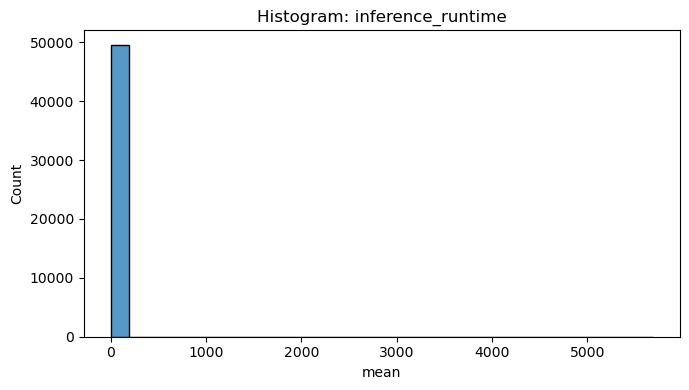

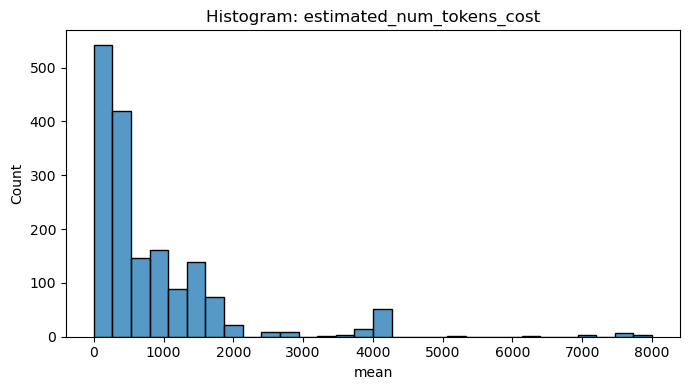

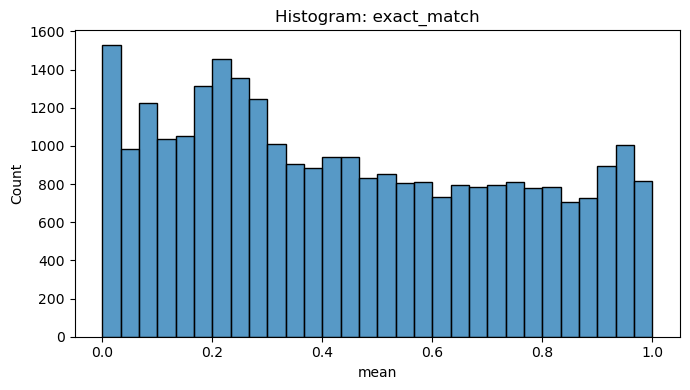

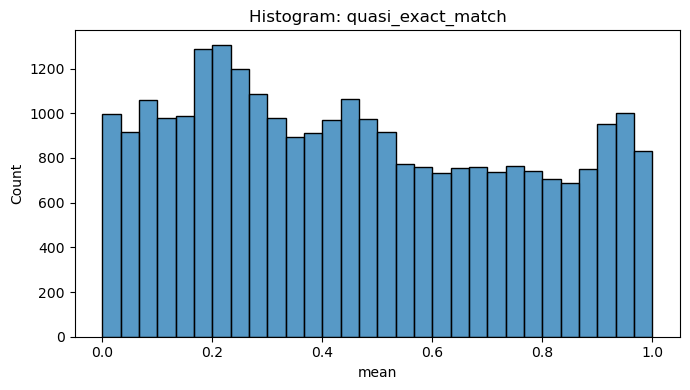

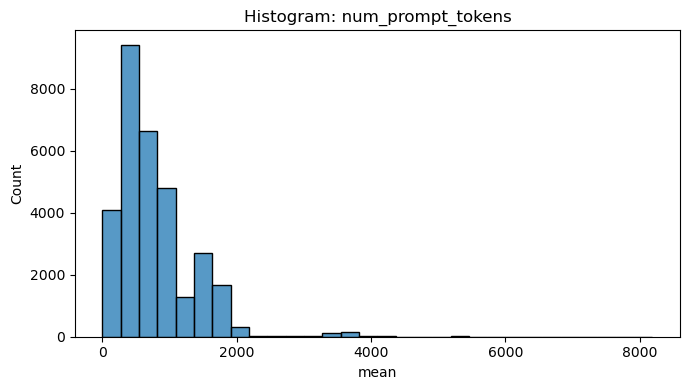

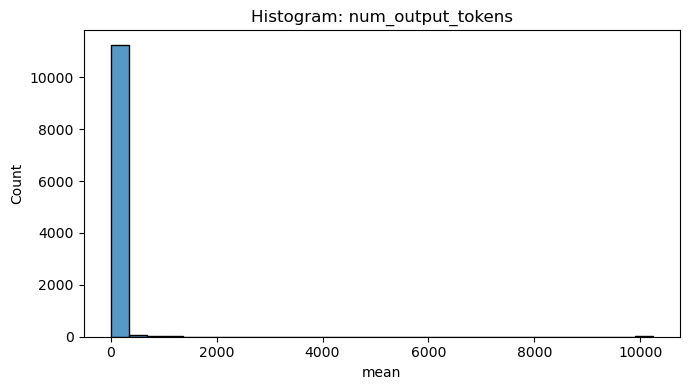

In [11]:
for m in metrics:
    x = helm_trim.loc[helm_trim["metric"] == m, "mean"].dropna()
    plt.figure(figsize=(7, 4))
    sns.histplot(x=x, bins=30)
    plt.title(f"Histogram: {m}")
    plt.xlabel("mean")
    plt.tight_layout()
    plt.show()

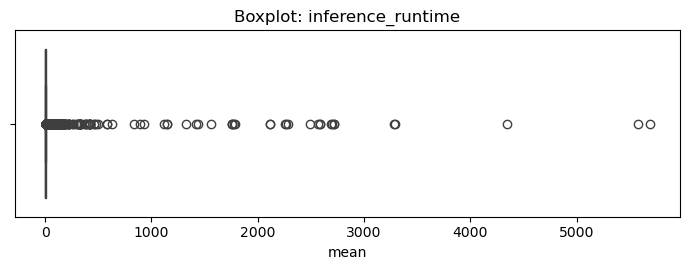

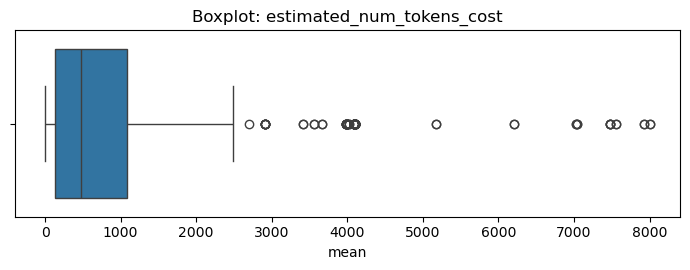

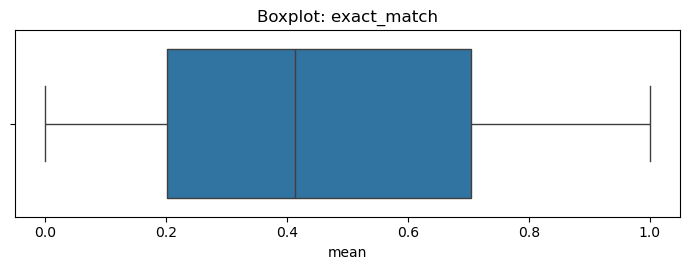

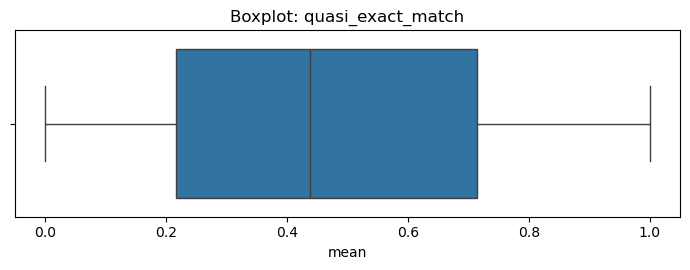

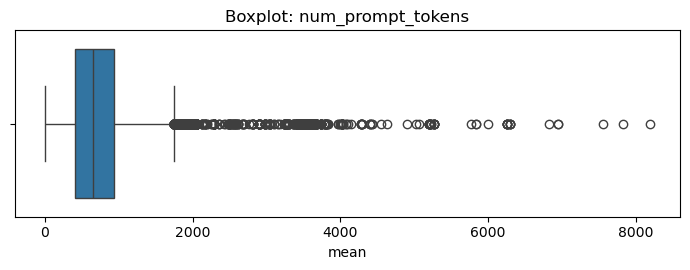

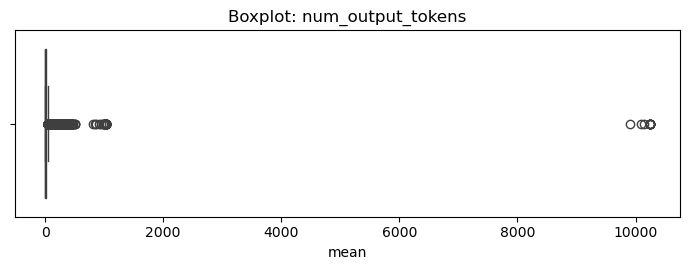

In [13]:
for m in metrics:
    x = helm_trim.loc[helm_trim["metric"] == m, "mean"].dropna()
    plt.figure(figsize=(7, 2.8))
    sns.boxplot(x=x)
    plt.title(f"Boxplot: {m}")
    plt.xlabel("mean")
    plt.tight_layout()
    plt.show()

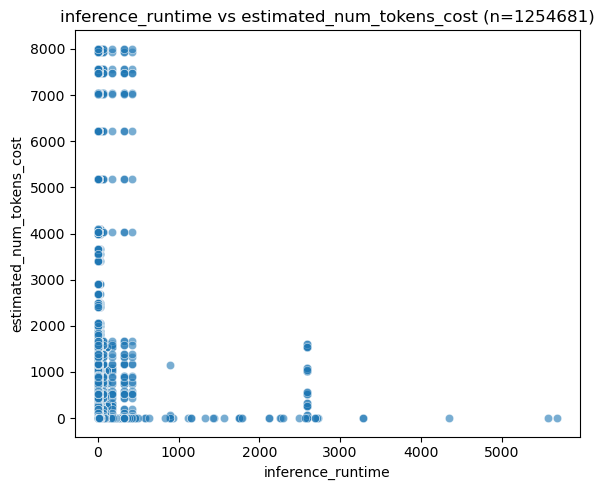

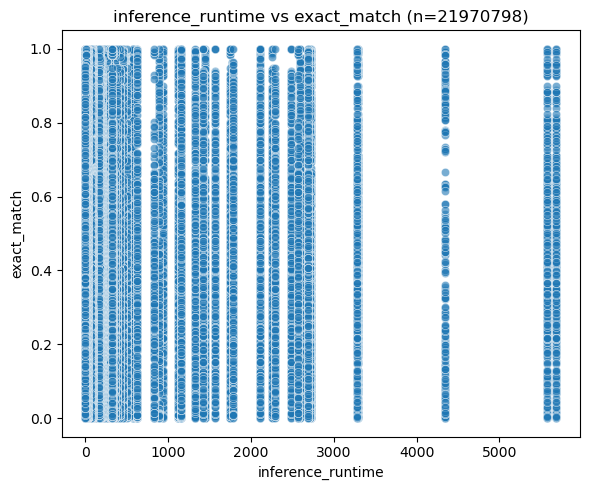

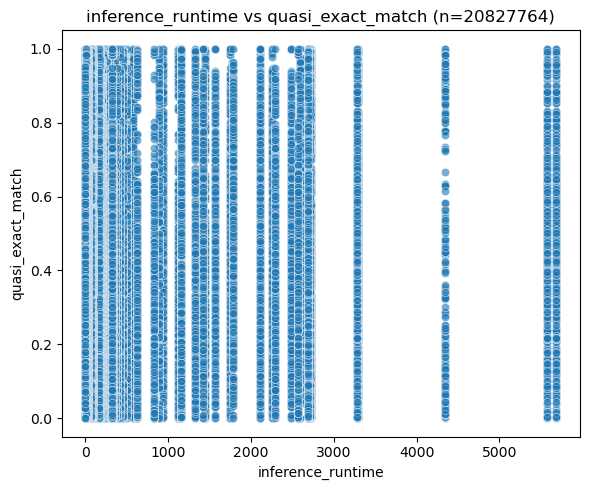

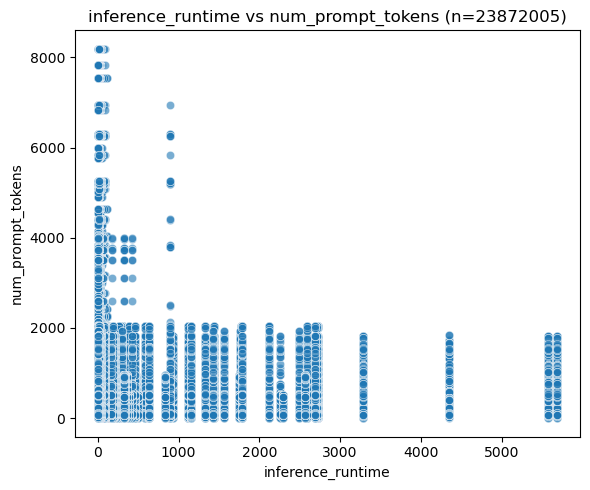

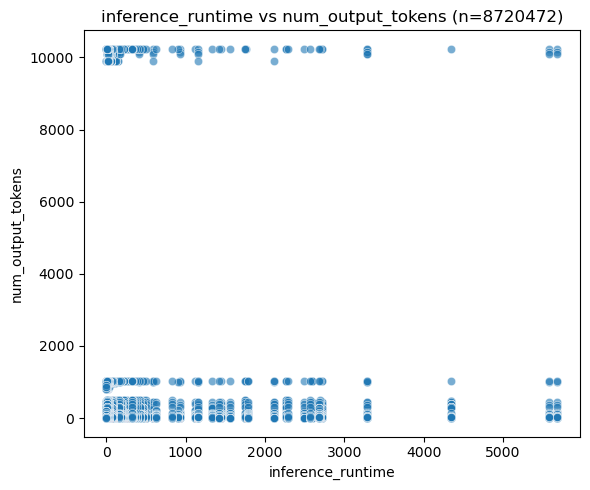

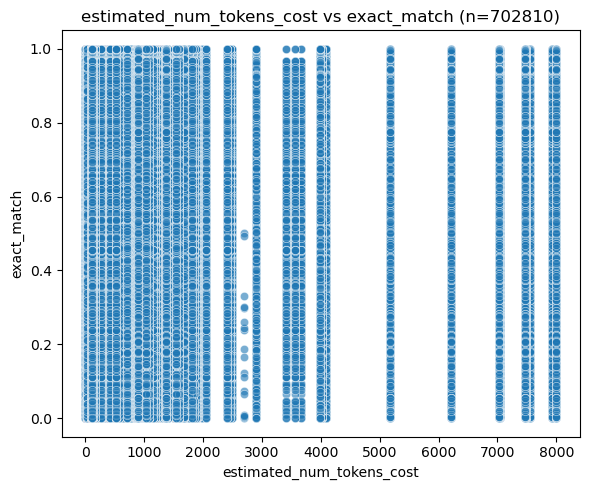

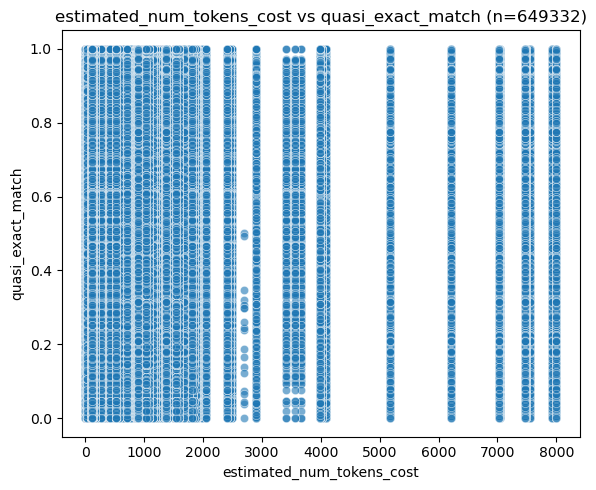

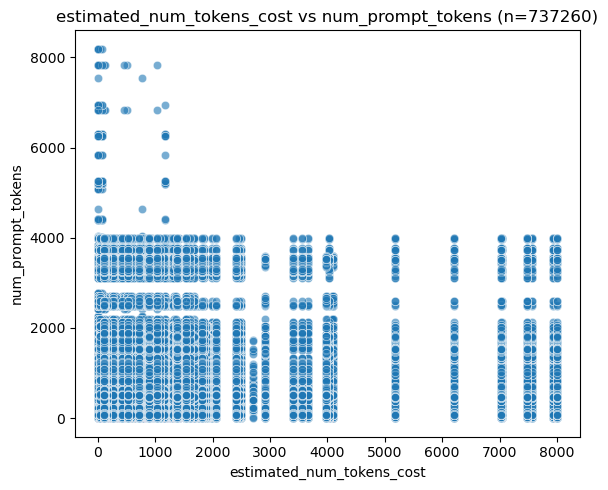

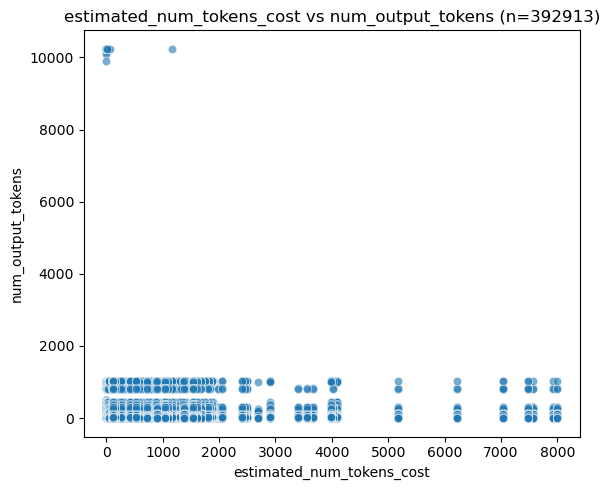

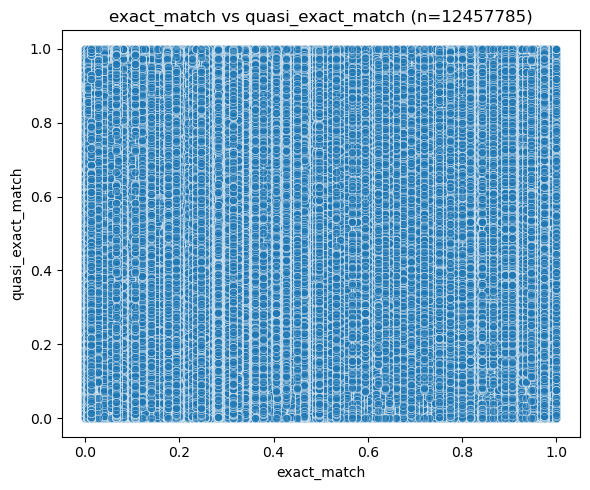

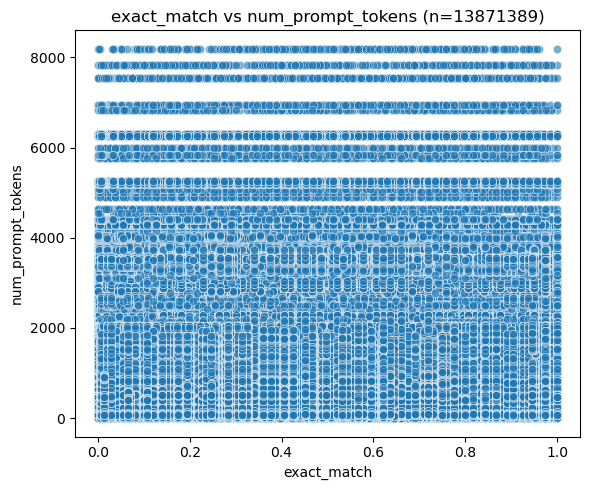

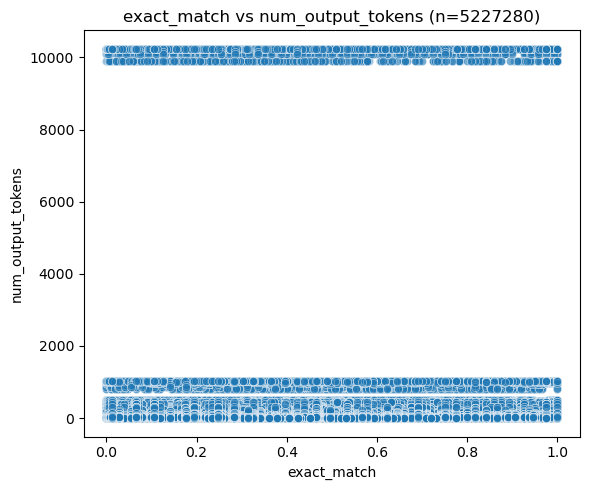

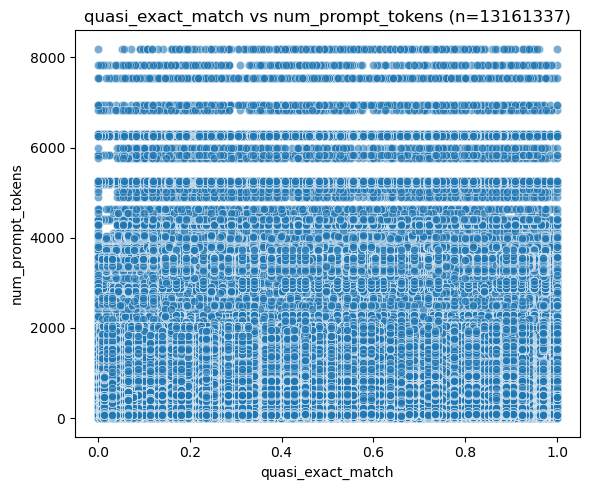

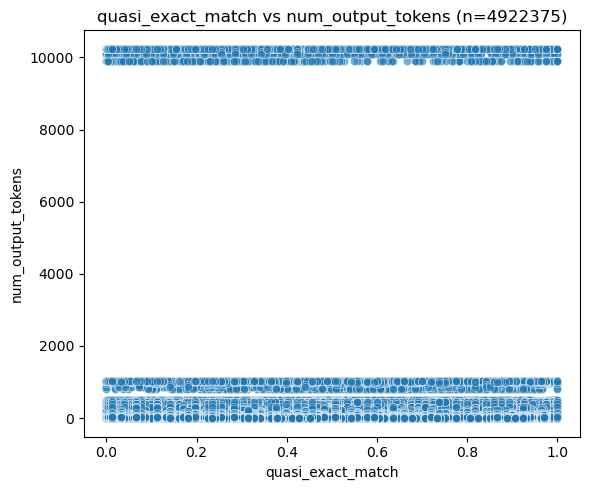

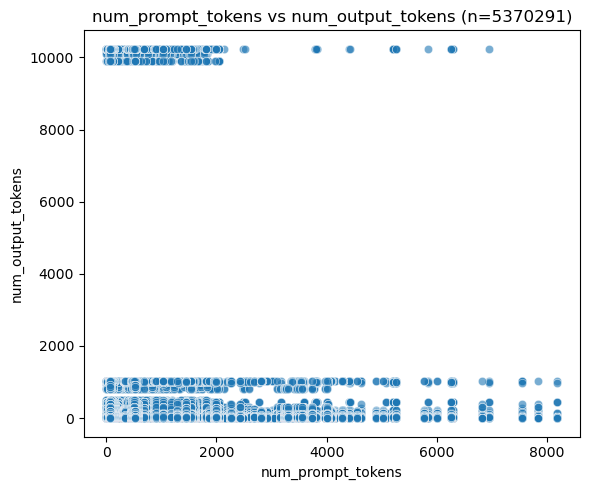

In [15]:
for m1, m2 in itertools.combinations(metrics, 2):
    a = helm_trim.loc[helm_trim["metric"] == m1, ["model", "mean"]].rename(columns={"mean": m1})
    b = helm_trim.loc[helm_trim["metric"] == m2, ["model", "mean"]].rename(columns={"mean": m2})
    pair = a.merge(b, on=["model"], how="inner").dropna()

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=pair, x=m1, y=m2, alpha=0.6)
    plt.title(f"{m1} vs {m2} (n={len(pair)})")
    plt.tight_layout()
    plt.show()

The only correlation supported by the histograms and boxplots is the correlation between `exact_match` and `quasi_exact_match`, but none between those two metrics and the energy cost ones. The scatterplots even further display the lack of correlation between these metrics. The histograms and boxplots show how the `num_prompt_tokens`, `num_output_tokens`, `inference_runtime`, and `estimated_num_tokens_cost` metrics have very unusual distributions that make this dataset unfit for answering our reserach question.

#### Section 2 — Epoch AI: Training compute vs parameters

This section examines whether larger models (more `Parameters`) tend to require more `Training compute (FLOP)` in the Epoch dataset. Both variables span many orders of magnitude, so we analyze them on a base-10 log scale. Because training compute is missing for a substantial fraction of rows, any compute-vs-parameter relationship is conditional on models with reported compute values. We report coverage first, then inspect univariate distributions, and finally plot compute versus parameters with a fitted trend.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

epoch_df = pd.read_json("data/Output/epoch_ai_parameters.ndjson", lines=True)
print(f"Epoch rows: {len(epoch_df):,} | columns: {epoch_df.shape[1]}")

required_cols = ["Parameters", "Training compute (FLOP)", "Domain", "Publication date"]
missing_required = [col for col in required_cols if col not in epoch_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

missing_cols = [
    "Parameters",
    "Training compute (FLOP)",
    "Training dataset size (total)",
    "Batch size",
    "Training chip-hours",
]
missing_tbl = pd.DataFrame({
    "missing_count": epoch_df[missing_cols].isna().sum(),
    "missing_frac": epoch_df[missing_cols].isna().mean(),
}).sort_values("missing_frac", ascending=False)

compute_reported = int(epoch_df["Training compute (FLOP)"].notna().sum())
print(f"Rows with non-missing training compute: {compute_reported:,} / {len(epoch_df):,}")
missing_tbl


Epoch rows: 1,403 | columns: 14
Rows with non-missing training compute: 815 / 1,403


,missing_count,missing_frac
Training chip-hours,1267,0.903065
Batch size,1200,0.855310
Training dataset size (total),674,0.480399
Training compute (FLOP),588,0.419102
Parameters,0,0.000000


#### Metadata Interpretation:
Based on the above metadata, Training compute is missing for a large share of models, so all compute-focused EDA below uses only the subset with reported compute values. If missingness is systematic (for example, certain model families reporting less often), the observed relationship can be biased relative to the full population.


In [5]:
# Positive-value filtering for log transforms
# Role: prepare a valid, analysis-ready subset for all downstream EDA plots and stats.
n_total = len(epoch_df)
n_params_valid = int(epoch_df["Parameters"].gt(0).sum())
n_compute_valid = int(epoch_df["Training compute (FLOP)"].gt(0).sum())

# Keep only rows where Parameters are strictly positive so log10 is defined.
epoch = epoch_df.loc[epoch_df["Parameters"].gt(0)].copy()
epoch["log10_params"] = np.log10(epoch["Parameters"])

# Restrict to rows with positive compute values; this subset drives compute-related plots.
epoch_compute = epoch.loc[epoch["Training compute (FLOP)"].gt(0)].copy()
epoch_compute["log10_train_flop"] = np.log10(epoch_compute["Training compute (FLOP)"])

n_pair = len(epoch_compute)

corr_log = epoch_compute["log10_params"].corr(epoch_compute["log10_train_flop"])
slope, intercept = np.polyfit(epoch_compute["log10_params"], epoch_compute["log10_train_flop"], 1)
print(f"log10 correlation (r): {corr_log:.3f}")
print(f"fitted line: log10_train_flop = {slope:.3f} * log10_params + {intercept:.3f}")


log10 correlation (r): 0.875
fitted line: log10_train_flop = 1.724 * log10_params + 5.208


#### Preprocessing Cell:
The above cell builds the clean subset used by every graph below. We keep only strictly positive values for `Parameters` and `Training compute (FLOP)` because `log10` is undefined for zero or negative values, then compute `n_pair`, correlation, and line-fit values that are reused in the relationship plot and its annotation. In short, this is the quality-control and feature-prep step that makes the downstream EDA valid and comparable.


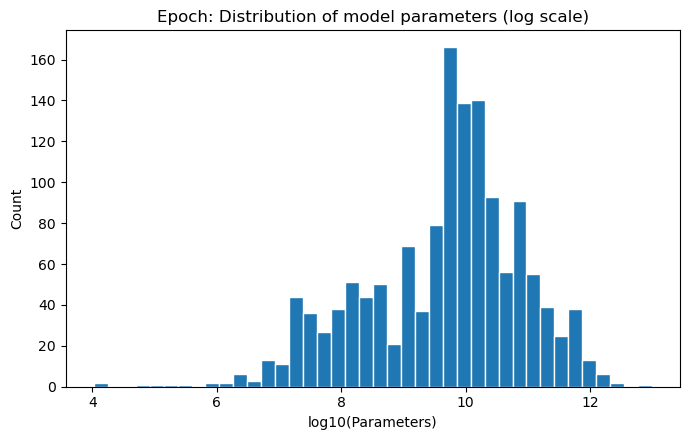

In [6]:
# Distribution of model parameters (log10)
plt.figure(figsize=(7, 4.5))
plt.hist(epoch["log10_params"].dropna(), bins=40, edgecolor="white")
plt.xlabel("log10(Parameters)")
plt.ylabel("Count")
plt.title("Epoch: Distribution of model parameters (log scale)")
plt.tight_layout()
plt.show()


#### Parameters distribution:
This first graph addresses the Section 2 setup by showing how model size is distributed before comparing it to compute. Most models cluster in specific log10 parameter bands rather than being evenly spread, which suggests the dataset is concentrated around common model scales. This matters because the relationship analysis should be interpreted in the context of where model-size density is highest.


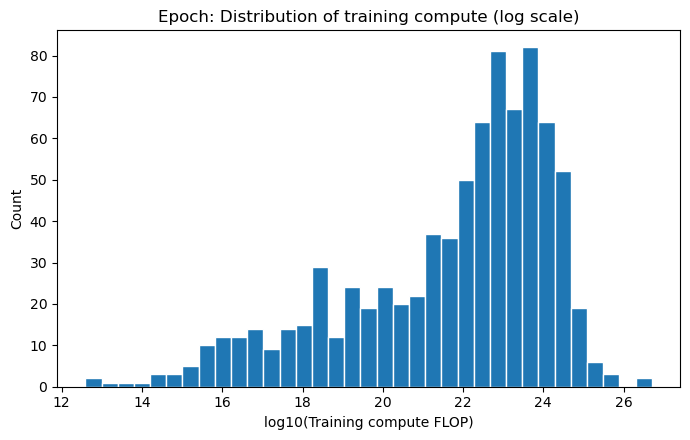

In [7]:
# Distribution of training compute (log10)
plt.figure(figsize=(7, 4.5))
plt.hist(epoch_compute["log10_train_flop"].dropna(), bins=35, edgecolor="white")
plt.xlabel("log10(Training compute FLOP)")
plt.ylabel("Count")
plt.title("Epoch: Distribution of training compute (log scale)")
plt.tight_layout()
plt.show()


#### Training compute distribution:

This second graph complements the first by showing the compute side of the same question, also on a log scale. Training compute is similarly broad across orders of magnitude, but this view is based only on rows with reported compute values, matching the missingness caveat in the section blurb. Together, the first two plots justify using a log-log relationship plot instead of raw-scale comparisons.


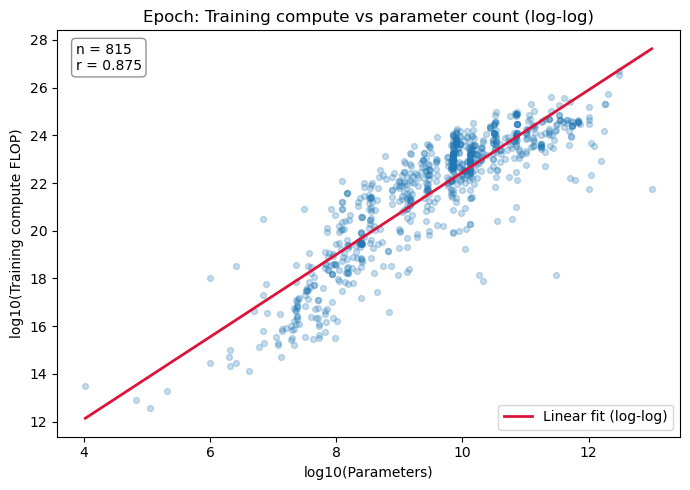

In [8]:
# Relationship: parameters vs training compute (both log10)
x = epoch_compute["log10_params"].to_numpy()
y = epoch_compute["log10_train_flop"].to_numpy()
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.25, s=18)
plt.plot(x_line, y_line, color="crimson", linewidth=2, label="Linear fit (log-log)")
plt.xlabel("log10(Parameters)")
plt.ylabel("log10(Training compute FLOP)")
plt.title("Epoch: Training compute vs parameter count (log-log)")
plt.legend()
plt.text(
    0.03,
    0.97,
    f"n = {n_pair:,}\nr = {corr_log:.3f}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "edgecolor": "gray"},
)
plt.tight_layout()
plt.show()


#### Relationship graph:

This final graph directly answers the question at the beginning of Section 2: as parameter count increases, required training compute also tends to increase. The upward trend line and strong reported correlation indicate a clear positive association in log space, not just a few outliers driving the pattern. Since this uses the reported-compute subset, the result is best interpreted as a strong conditional relationship rather than a guaranteed pattern for all models in the full dataset.


#### Section 3 -- Huggingface.co OpenLLMLeaderboard

Huggingface uniquely gives a direct environmental variable we can compare models to. Additionally, as a leaderboard, they include metrics for performace across various LLM tasks, as well as normalized and average scores for each of them.
Packages are first imported, and the data made ready for analysis.

In [9]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# load huggingface dataset
src = "./data/Output/hf_parameters_co2.ndjson"
hf = pl.scan_ndjson(src)

# unnest specific benchmarks (json origin)
benchmarks = ["bbh", "gpqa", "ifeval", "math", "mmlu_pro", "musr",]
for bench in benchmarks:
    hf = hf.with_columns(pl.col(bench).list.first().alias(bench))
    hf = hf.unnest(bench, separator="_")

# drop unnecesscary name cols
hf = hf.drop([col for col in hf.collect_schema().names() if "_name" in col])

# drop nulls for data we look at. Previous drops only uncluded nulls for parameter counts. 
# Collects dataframe into eager.
hf = hf.drop_nulls(pl.selectors.matches("co2_cost|_value")).collect()
x_vars=[
    "parameters",
    "bbh_value",
    "gpqa_value",
    "ifeval_value",
    "math_value",
    "mmlu_pro_value",
    "musr_value",
]

The first step is to take a glimpse at the data. polars.describe() generates summary statistics, which we show the entirety of by changing the config.
We are also curious at what type of relationship these variables have with one another, but most importantly, the co2_cost variable. 

In [10]:
# Describe variables
print("Expand / Zoom out if tables do not show properly. GitHub Text-Wraps instead of horizontal scrolling.")
with pl.Config(tbl_cols=100, tbl_width_chars=150, set_fmt_float="mixed", float_precision=3, ):
    print("Summary Statistics for HuggingFace Dataset (truncated decimals for visibility)")
    print(hf.drop([
        "architecture",
        "model",
        "precision",
        "name",

    ]).describe())

normalized_numeric = [
    "co2_cost",
    "parameters",
    "average_score",
    "bbh_normalized_score",
    "gpqa_normalized_score",
    "ifeval_normalized_score",
    "math_normalized_score",
    "mmlu_pro_normalized_score",
    "musr_normalized_score",
]


# Correlation Matrix
corr_df = hf.with_columns([
    pl.col('co2_cost').log1p().alias('log_co2'),
])
corr_df = corr_df.select(["log_co2"] + [col for col in normalized_numeric if col not in ["co2_cost"]]).corr()
with pl.Config(tbl_cols=100, tbl_width_chars=150):
    print("Correlation Matrix for Numerical Variables")
    print(corr_df)

Expand / Zoom out if tables do not show properly. GitHub Text-Wraps instead of horizontal scrolling.
Summary Statistics for HuggingFace Dataset (truncated decimals for visibility)
shape: (9, 16)
┌─────────┬─────────┬─────────┬─────────┬─────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ statist ┆ average ┆ co2_cos ┆ paramet ┆ bbh_val ┆ bbh_no ┆ gpqa_v ┆ gpqa_n ┆ ifeval ┆ ifeval ┆ math_v ┆ math_n ┆ mmlu_p ┆ mmlu_p ┆ musr_v ┆ musr_n │
│ ic      ┆ _score  ┆ t       ┆ ers     ┆ ue      ┆ rmaliz ┆ alue   ┆ ormali ┆ _value ┆ _norma ┆ alue   ┆ ormali ┆ ro_val ┆ ro_nor ┆ alue   ┆ ormali │
│ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ed_sco ┆ ---    ┆ zed_sc ┆ ---    ┆ lized_ ┆ ---    ┆ zed_sc ┆ ue     ┆ malize ┆ ---    ┆ zed_sc │
│ str     ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ re     ┆ f64    ┆ ore    ┆ f64    ┆ score  ┆ f64    ┆ ore    ┆ ---    ┆ d_scor ┆ f64    ┆ ore    │
│         ┆         ┆         ┆         ┆         

Immediately, we have some insights into "co2_cost". We can see the results are all clustered around the single-digit mark, but with significant outliers. Each benchmark and average is also present, allowing us to draw some comparisons between cost, parameter, and co2_cost.

Notice the correlation matrix generated uses "log_co2", as the original "co2_cost" is similar to an ~Exponential() distribution.
Below, let's now look at the distribution of the "co2_cost" in question, as well as in log form.

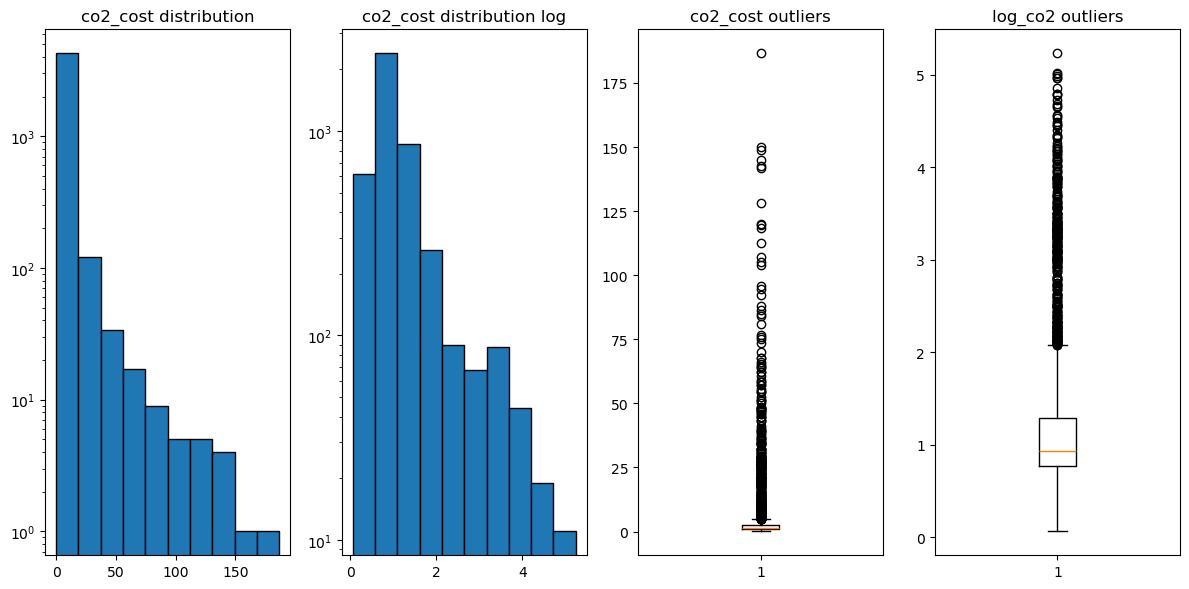

In [11]:
co2 = hf.select("co2_cost").to_numpy().flatten()

# generate plots to look at co2_cost
fig, axs = plt.subplots(1, 4, figsize=(12, 6))
axs[0].hist(co2, edgecolor="black")
axs[0].set_title("co2_cost distribution")
axs[0].set_yscale("log")

log = np.log1p(co2)
axs[1].hist(log, edgecolor="black")
axs[1].set_title("co2_cost distribution log")
axs[1].set_yscale("log")

axs[2].boxplot(co2, vert=True)
axs[2].set_title('co2_cost outliers')

axs[3].boxplot(log, vert=True)
axs[3].set_title('log_co2 outliers')

plt.tight_layout()
plt.show()

The left two plots illustrate the distribution as a histogram, with a logscale for y. We can see the aformentioned exponential-like distribution, where even as a log scale we see heavy-left leaning data. The right 2 plots show outliers, which matplotlib illustrates as circles for entries beyond Quartile 3 + 1.5% of Inter-Quartile Range. Even in log form, there are several outliers.

Taking a step back, we can look temporarily at how HuggingFace generates this "cost_co2" metric: 

*The [sic] calculate_co2_emissions() function estimates CO₂ emissions in kilograms for a given evaluation time in seconds, assuming the workload is running on 8 NVIDIA H100 SXM GPUs in Northern Virginia.*

Their calculations are based on runtime, and variables for power consumption per time, cost of power, co2 emissions per kWh.
In this context, these exponential results make sense: Newer models face a Pareto-paradox where improvements will cost more time and resources for less overall improvement. But by how much? While we don't get to this question in this section, this is the question we are trying to answer.

Next, let's look at the numerical variables for benchmarks.

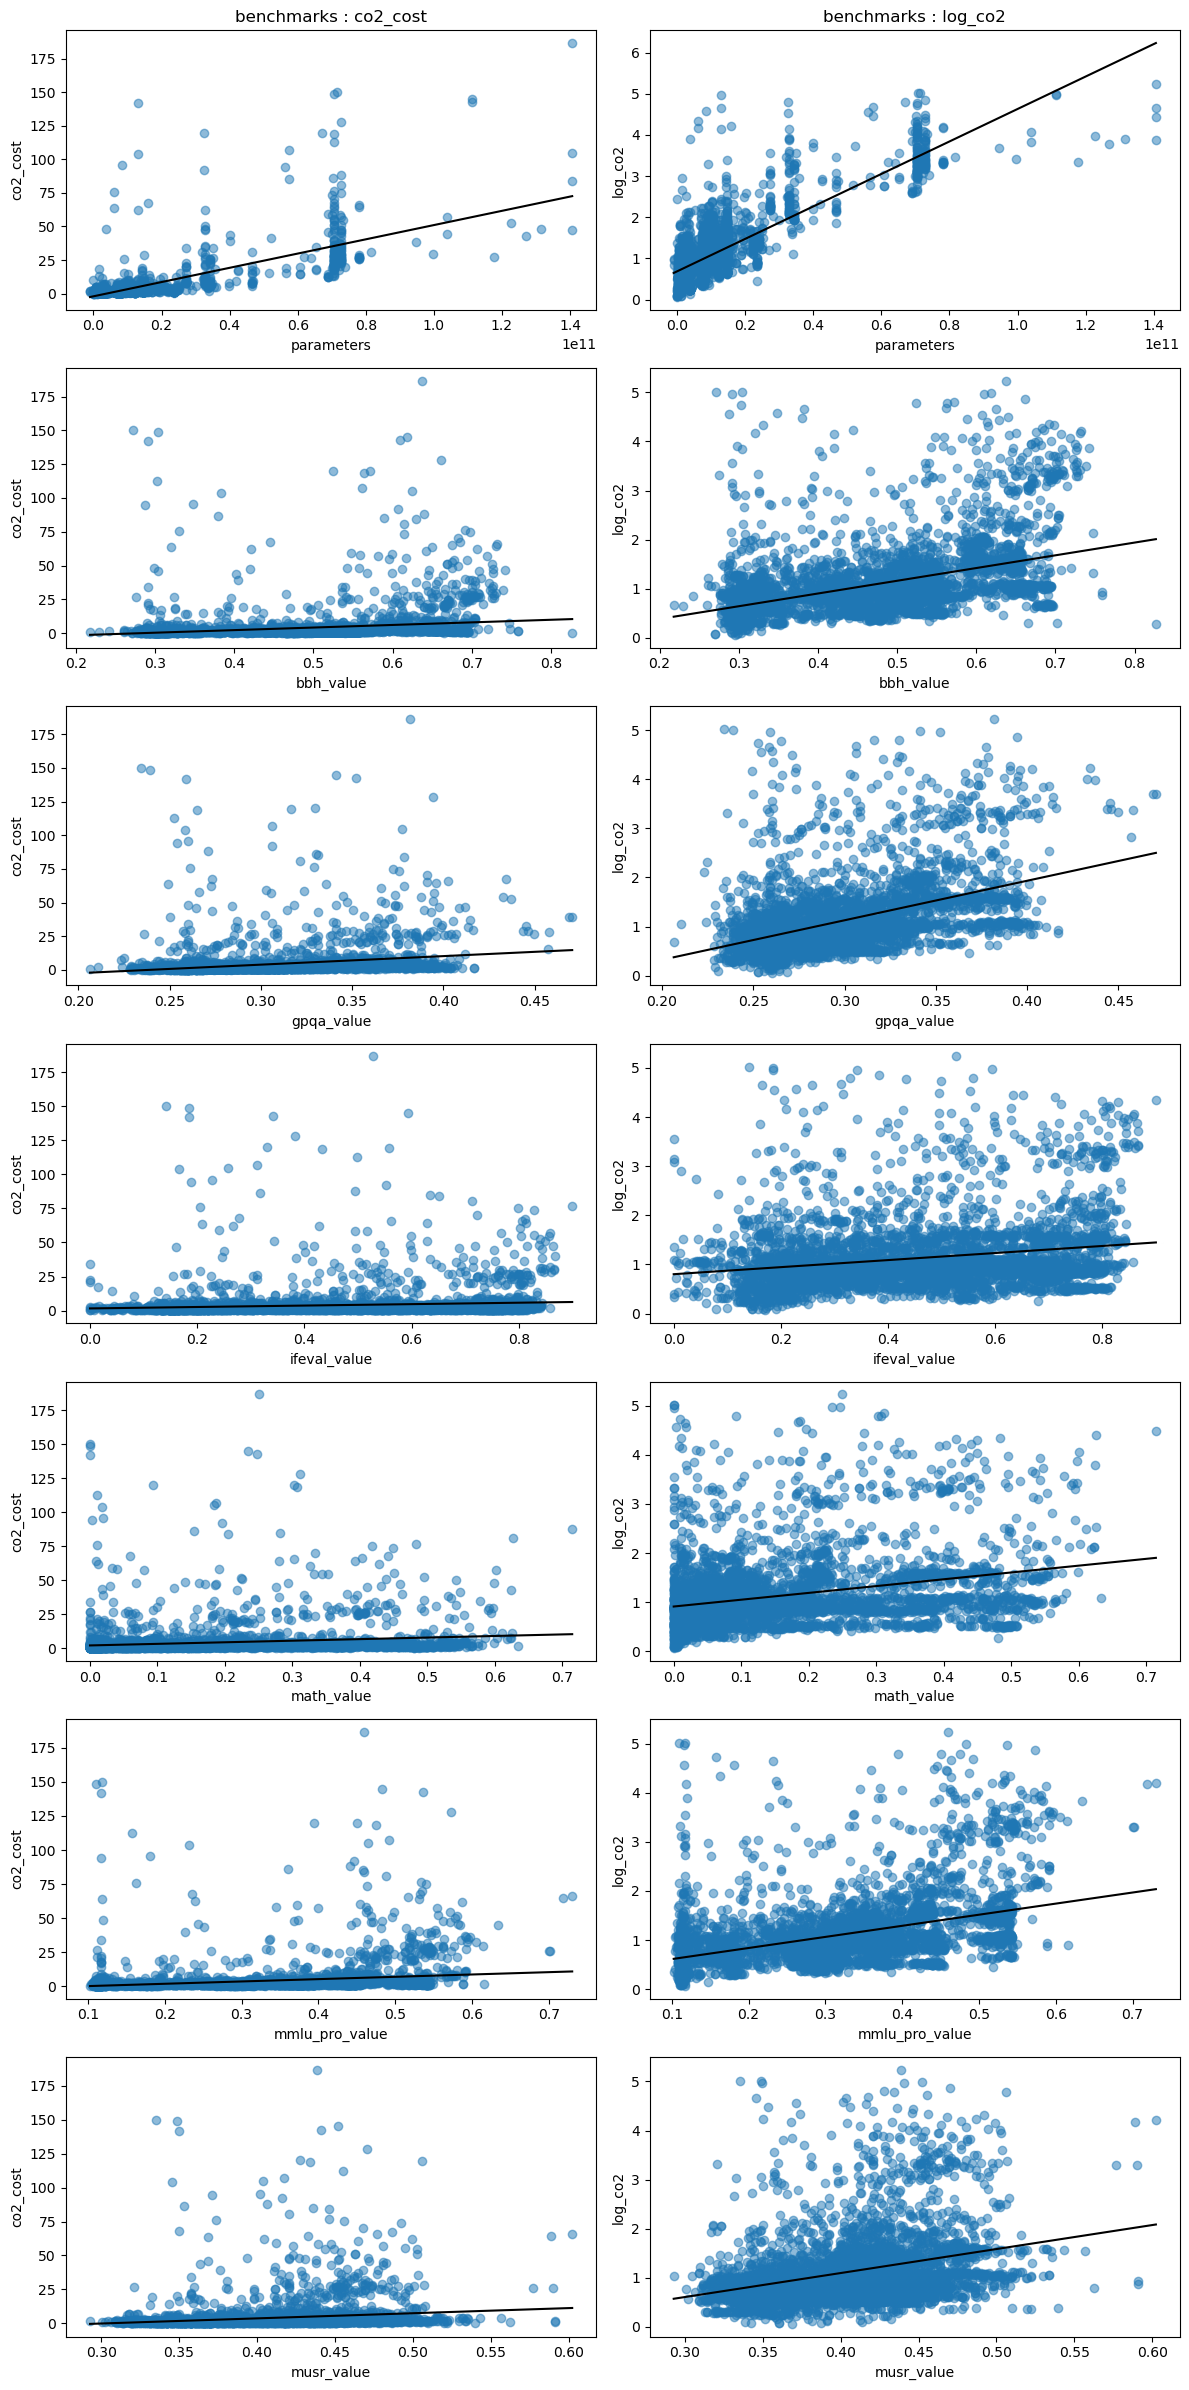

In [12]:
# This code below generates benchmark to co2 subplots, vertically.
fig, axs = plt.subplots(len(x_vars), 2, figsize=(12, 24))
axs = axs.flatten(order="F")
axs[0].set_title("benchmarks : co2_cost")
axs[7].set_title("benchmarks : log_co2")
for var in range(len(x_vars)):
    x = hf.select(x_vars[var]).to_numpy().flatten()
    m, b = np.polyfit(x, co2, 1)
    regline = np.linspace(x.min(), x.max())
    axs[var].scatter(hf.select(x_vars[var]).to_numpy(), co2, alpha=0.5)
    axs[var].plot(regline, m*regline+b, color="black")
    axs[var].set_xlabel(x_vars[var])
    axs[var].set_ylabel(f"co2_cost")

for var in range(len(x_vars)):
    x = hf.select(x_vars[var]).to_numpy().flatten()
    m, b = np.polyfit(x, log, 1)
    regline = np.linspace(x.min(), x.max())
    axs[var+len(x_vars)].scatter(hf.select(x_vars[var]).to_numpy(), log, alpha=0.5)
    axs[var+len(x_vars)].plot(regline, m*regline+b, color="black")
    axs[var+len(x_vars)].set_xlabel(x_vars[var])
    axs[var+len(x_vars)].set_ylabel(f"log_co2")


plt.tight_layout()
plt.show()

From this analysis, we can ascertain a relationship between co2_cost and parameters, as well as co2_cost and benchmarks. We see a degree of linearity / correlation between most, but with many upward outliers for "co2_cost" and "log_co2". This makes sense as not everyone is successful at training an efficient model. More inputs, more parameters, more computation cost doesn't relate directly to a "good" LLM output. This is none more obvious than in tests such as math and mmlu_pro, where we see scores of 0 with high co2 costs. 
Going forward in analysis, we will explore this relationship closer.

Next let's take a glimpse at the 2 catagorical variables we have, architecture of the LLM and Precision. Architecture is for families of models, and precision is the precision the model works at, demonstrating a tradeoff between accuracy and speed.

In [13]:
print("List of architectures in HuggingFace Dataset")
print(hf.select(pl.col("architecture")).unique().sort(by="architecture").head(10).to_numpy())

List of architectures in HuggingFace Dataset
[['']
 ['?']
 ['AriaForConditionalGeneration']
 ['BloomForCausalLM']
 ['ChatGLMModel']
 ['ChatGLMModelM']
 ['Cohere2ForCausalLM']
 ['CohereForCausalLM']
 ['DbrxForCausalLM']
 ['DeciLMForCausalLM']]


Architecture isn't very informative, and is less useful with many categories and not many models in each category, however can be used as a point of comparison.
Precision only has 3 categories, and we can illustrate some differences between them.

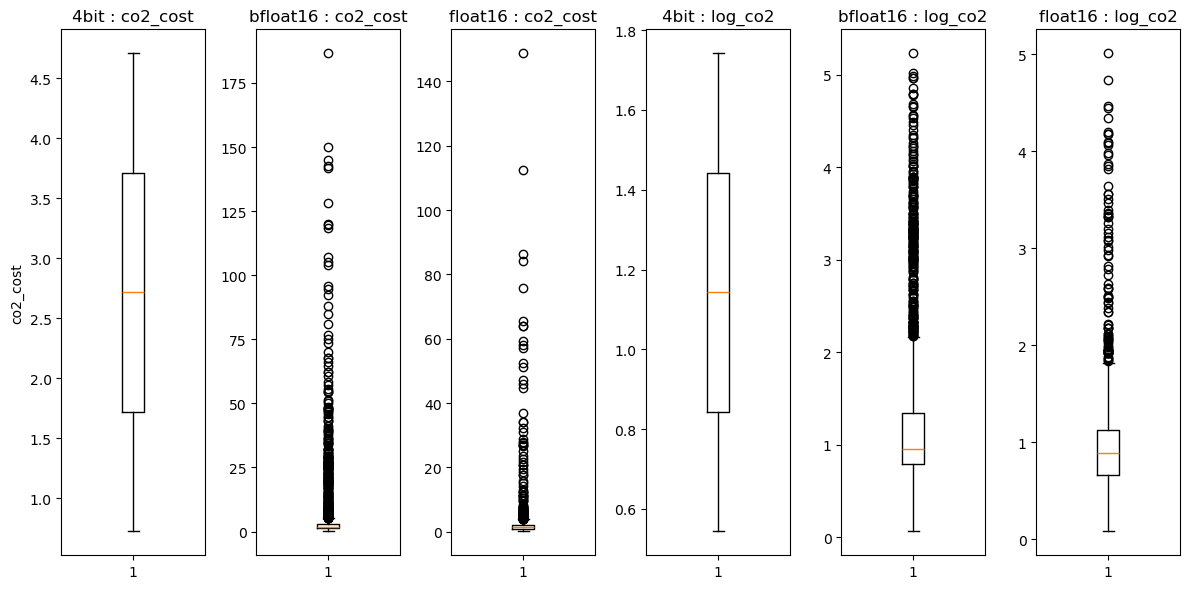

In [14]:
# Catagorical Variable analysis
fig, axs = plt.subplots(1, 6, figsize=(12, 6))
log = hf.with_columns([
    pl.col("co2_cost").log1p().alias("log_co2")
])
precision = hf.select("precision").unique().sort(by="precision").to_numpy().flatten()

axs[0].set_ylabel("co2_cost")
axs[0].set_title("Precision : co2_cost")

for cat in range(len(precision)):
    axs[cat].boxplot(hf.filter(pl.col("precision")==precision[cat]).select("co2_cost"))
    axs[cat].set_title(f"{precision[cat]} : co2_cost")

for cat in range(len(precision)):
    axs[cat+3].boxplot(log.filter(pl.col("precision")==precision[cat]).select("log_co2"))
    axs[cat+3].set_title(f"{precision[cat]} : log_co2")


plt.tight_layout()
plt.show()

4bit only has a few entries, we later can draw comparisons between the other categories of "bfloat16" and "float16".

## Ethics

## Ethics 


### A. Data Collection
 - [ ] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?


> Data sources regarding the computational cost of generative AI are often opaque. The datasets we use come from independent groups evaluating models in different environments, so source-specific assumptions (hardware, runtime setup, and reporting conventions) can bias comparisons. We account for this by documenting source provenance and avoiding claims that depend on perfect cross-source equivalence.


 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?


> We only collect model-level metadata and benchmark/compute metrics (for example model name, score, FLOPs proxy, and CO2 proxy). No user-level or personal records are used, and nonessential fields are dropped during cleaning to minimize unnecessary data exposure.


 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?


### B. Data Storage
 - [ ] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?


 > CFRM HELM explicitly asks: “...you do not reveal examples from this dataset in plain text or images online, to minimize the risk of these instances being included in foundation model training corpora.” We follow these usage constraints and retain only project-relevant processed outputs needed for reproducibility.


### C. Analysis
 - [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?


> Upstream confounding variables are a major risk (for example, inference runtime can be confounded by parallelization and hardware allocation). Since each source computes cost-related metrics differently, we treat these as proxies, preserve source-specific context, and avoid overinterpreting them as direct causal measures. The sources we've found so far have each independently calculated a CO_2 Cost for each model, and we will need to take their assumptions and build upon that to compare models based on environmental impact. Not only that, our sources for data are few and far between, as is the nature of analyzing a frontier model. We do not have the computational power to run our own inference, and will depend on the sources we can find.


 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?


> We explicitly frame our findings as observational and proxy-based, report limitations near each major result, and avoid visual choices that imply unsupported precision. Any cross-dataset comparisons are labeled with assumptions and caveats.


 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?


> Our analysis uses only public model benchmark and compute fields and does not include PII. We do not publish raw prompt/response examples from restricted benchmark sources.


 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?


 > Our analysis will be purely based on the data we have. The analysis will be diluted by the method of cleaning data we have, however, we plan for our analysis to be straightforward, based on the data we collect.


### D. Modeling
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 
 > Comparing language models on environmental cost alone would be too narrow. We therefore pair efficiency-related measures with performance benchmarks to avoid making recommendations based on a single metric.


 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?


> We are not training a new predictive model; we are analyzing public benchmark/compute data. Our methods and conclusions are intended to be interpretable through direct summary statistics, visualizations, and clearly stated assumptions.


 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?


> We will communicate the limitations of our analysis within our report. Notable limitations we face are the use of proxies for the environmental impact of LLMs. 


### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

1. Respond in group chat within 24 hours

2. If you cannot make a meeting/ deadline, tell the group early 

3. Tasks are assigned with a clear owner + due time

4. Do your part in completing the work before our weekly meeting, as to keep the work flowing. 

5. Be respectful in feedback; disagreements = suggestions + reason

6. Stay proactive. Our team meets are on Thursday, so if an assignment is due before then, work on it early.

7. Questions are to be asked, not kept in your head.. 


## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 01/29  |  18:00  | Introductions, communicate meeting times and expectations; Brainstorm topics / questions related to AI | Completed Project Review Assignment | 
| 02/02  |  16:00 |  Look for applicable datasets to narrow our topic selection; Brainstorming specific AI-related question  | Looking for datasets, discussing how to narrow our question based on the Data, plan meeting to finish 00-ProjectProposal | 
| 02/04  | 19:00  | Edit, finalize Project Proposal  |  **Complete Checkpoint #0, Project Proposal**; Group Check-In  |
| 02/05  | 18:00  | Getting Data from epoch.ai & CRFM HELM. (et. al.) | Discuss Data format, cleaning, important data metrics; Discussing Programs & Packages used for analysis, analysis plan  |
| 02/12  | 18:00  | Work on Data Wrangling / Cleaning | **Complete Checkpoint #1 Data**; Discuss Analysis plans / outputs and Datavis |
| 02/19  | 18:00  | Work on Data Wrangling -> Analysis | Group Check-In; Discuss Analysis |
| 02/26  | 18:00  | Work on Data Analysis -> DataVis | **Complete Checkpoint #2: EDA**; Group Check-In |
| 03/05  | 18:00  | Work on Datavis -> Final Report + Video | Group Check-In; Discuss Final Sumbmission |
| 03/1x  | TBD  | Work on Datavis -> Final Report + Video |  *Week 10, meeting TBD (finals)*; Group Check-In  |
| 03/1x  | TBD | Finalize Project Submission | Turn in Final Project |